# DS 4320 Project 1: Detecting Credit Card Fraud
**Author:** Emujin Batzorig  **Pipeline:** Load → SQL Features → Random Forest → Evaluate → Visualize

Please upload the 4 tables manually before running the code.

## Stage 1 — Imports & Setup

In [ ]:
import logging, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix, precision_recall_curve
)

logging.basicConfig(filename="pipeline.log", level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

os.makedirs("results", exist_ok=True)
RANDOM_SEED = 42
SAMPLE_N    = 500_000
np.random.seed(RANDOM_SEED)
print("Imports complete.")


Imports complete.


## Stage 2 — Load Tables into DuckDB

In [ ]:
import duckdb
import os

con = duckdb.connect()

FILE_MAP = {
    "customers": "/content/customers.parquet",
    "cards": "/content/cards.parquet",
    "merchants": "/content/merchants.parquet",
    "transactions": "/content/transactions.parquet",
}

for table, path in FILE_MAP.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing uploaded file for {table}: {path}")

    if path.endswith(".parquet"):
        src = f"read_parquet('{path}')"
    elif path.endswith(".csv"):
        src = f"read_csv_auto('{path}')"
    else:
        raise ValueError(f"Unsupported file type for {table}: {path}")

    con.execute(f"CREATE OR REPLACE TABLE {table} AS SELECT * FROM {src}")
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table:<14} {n:>11,} rows loaded from {path}")

customers            1,000 rows loaded from /content/customers.parquet
cards                1,264 rows loaded from /content/cards.parquet
merchants              800 rows loaded from /content/merchants.parquet


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

transactions    10,000,000 rows loaded from /content/transactions.parquet


## Stage 3 — SQL Feature EngineeringJoin all 4 tables and engineer cross-entity features.

In [ ]:
FEATURE_SQL = '''
SELECT
    t.trans_id, t.is_fraud, t.amt,
    EXTRACT(hour  FROM CAST(t.trans_date_trans_time AS TIMESTAMP)) AS trans_hour,
    EXTRACT(dow   FROM CAST(t.trans_date_trans_time AS TIMESTAMP)) AS trans_dow,
    EXTRACT(month FROM CAST(t.trans_date_trans_time AS TIMESTAMP)) AS trans_month,
    m.risk_rating, m.category,
    ca.credit_limit, ca.card_type,
    DATE_DIFF('year', CAST(cu.dob AS DATE), CURRENT_DATE)          AS cust_age,
    cu.city_pop,
    ROUND(t.amt / NULLIF(ca.credit_limit, 0), 6)                   AS utilisation_ratio,
    ROUND(SQRT(POWER(cu.lat - m.merch_lat, 2) +
               POWER(cu.long - m.merch_long, 2)), 6)               AS geo_distance
FROM transactions t
JOIN cards        ca ON t.card_id     = ca.card_id
JOIN merchants    m  ON t.merchant_id = m.merchant_id
JOIN customers    cu ON ca.customer_id = cu.customer_id
'''

df_full = con.execute(FEATURE_SQL).df()
print(f"Full matrix: {len(df_full):,} rows x {df_full.shape[1]} cols")
print(f"Fraud rate : {df_full['is_fraud'].mean()*100:.2f}%")

# Stratified sample
fraud_df = df_full[df_full['is_fraud']==1]
legit_df = df_full[df_full['is_fraud']==0]
n_fraud  = min(len(fraud_df), int(SAMPLE_N * df_full['is_fraud'].mean()))
n_legit  = SAMPLE_N - n_fraud
df = pd.concat([
    fraud_df.sample(n_fraud, random_state=RANDOM_SEED),
    legit_df.sample(n_legit, random_state=RANDOM_SEED),
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"Sample     : {len(df):,} rows (fraud={n_fraud:,}, legit={n_legit:,})")
df.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Full matrix: 10,000,000 rows x 14 cols
Fraud rate : 2.00%
Sample     : 500,000 rows (fraud=10,016, legit=489,984)


,trans_id,is_fraud,amt,trans_hour,trans_dow,trans_month,risk_rating,category,credit_limit,card_type,cust_age,city_pop,utilisation_ratio,geo_distance
0,5862678,0,35.639999,11,0,5,medium,gas_transport,5400.0,Mastercard,38,1416593,0.006600,18.394174
1,6594811,0,27.150000,6,2,6,low,kids_pets,2800.0,Mastercard,34,1321786,0.009696,20.723848
2,239307,0,29.580000,19,0,1,low,education,5000.0,Visa,44,2059927,0.005916,9.047715
3,2687917,0,41.180000,14,4,3,medium,food_dining,7100.0,Mastercard,62,268587,0.005800,5.464947
4,849785,0,48.349998,23,4,1,medium,grocery_pos,10300.0,Visa,58,716282,0.004694,2.175094


## Stage 4 — Prepare ML Features

In [ ]:
df_ml = pd.get_dummies(df, columns=['risk_rating','category','card_type'], drop_first=True)
df_ml = df_ml.drop(columns=['trans_id']).dropna()

LABEL    = 'is_fraud'
features = [c for c in df_ml.columns if c != LABEL]
X = df_ml[features].astype(float)
y = df_ml[LABEL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}   Features: {len(features)}")


Train: 400,000   Test: 100,000   Features: 27


## Stage 5 — Train Random Forest`class_weight='balanced'` adjusts for the ~2% fraud minority without resampling.

In [ ]:
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)
clf.fit(X_train, y_train)
print("Training complete.")


Training complete.


## Stage 6 — EvaluatePR-AUC is the primary metric for imbalanced fraud data. Random baseline ≈ 0.02.

In [ ]:
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  (random baseline ≈ 0.02)")
print()
print(classification_report(y_test, y_pred, target_names=['Legit','Fraud']))


ROC-AUC : 0.8248
PR-AUC  : 0.1895  (random baseline ≈ 0.02)

              precision    recall  f1-score   support

       Legit       0.99      0.87      0.93     97997
       Fraud       0.09      0.61      0.15      2003

    accuracy                           0.86    100000
   macro avg       0.54      0.74      0.54    100000
weighted avg       0.97      0.86      0.91    100000



## Stage 7 — Visualizations

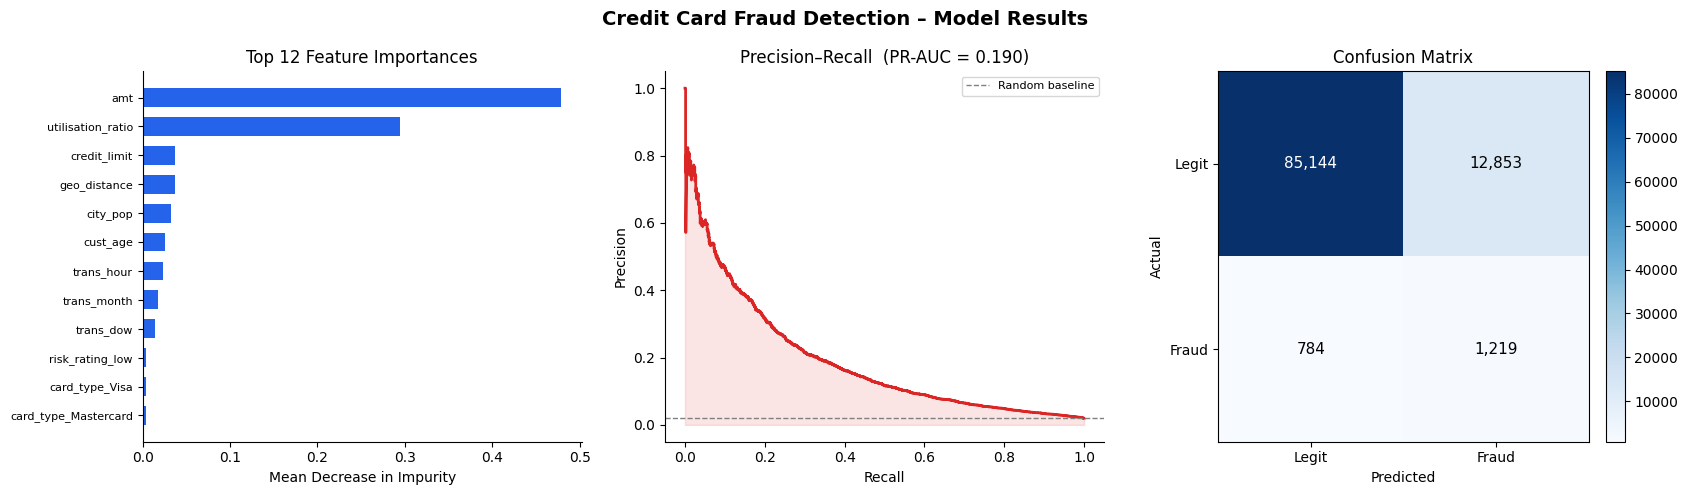

Saved: results/fraud_detection_results.png


In [ ]:
# Figure 1: 3-panel model results
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Credit Card Fraud Detection – Model Results", fontsize=14, fontweight="bold")

# Panel A: Feature importances
imp = pd.Series(clf.feature_importances_, index=features).nlargest(12)
axes[0].barh(imp.index[::-1], imp.values[::-1], color="#2563EB", height=0.65)
axes[0].set_title("Top 12 Feature Importances")
axes[0].set_xlabel("Mean Decrease in Impurity")
axes[0].tick_params(axis='y', labelsize=8)
for sp in ['top','right']: axes[0].spines[sp].set_visible(False)

# Panel B: PR curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, color="#DC2626", lw=2)
axes[1].fill_between(recall, precision, alpha=0.12, color="#DC2626")
axes[1].axhline(y=0.02, color="gray", linestyle="--", lw=1, label="Random baseline")
axes[1].set_title(f"Precision–Recall  (PR-AUC = {pr_auc:.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)
for sp in ['top','right']: axes[1].spines[sp].set_visible(False)

# Panel C: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(["Legit","Fraud"]); axes[2].set_yticklabels(["Legit","Fraud"])
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
axes[2].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm[i,j]:,}", ha='center', va='center', fontsize=11,
            color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("results/fraud_detection_results.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: results/fraud_detection_results.png")


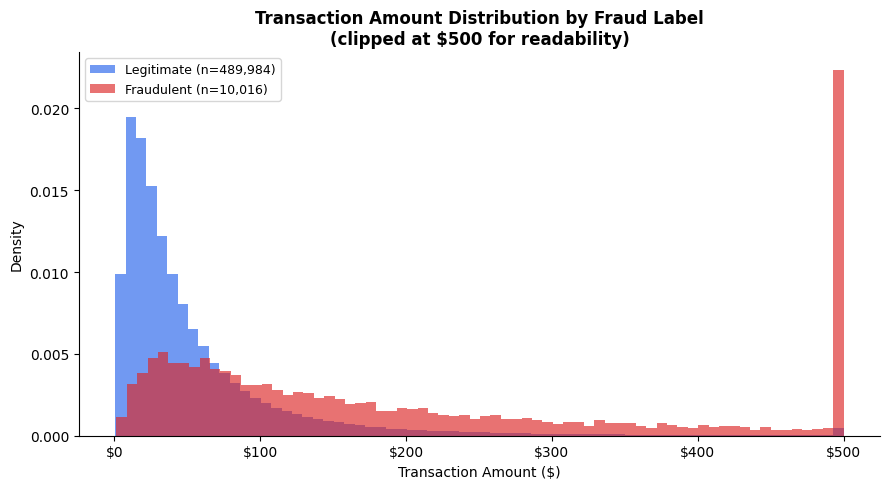

Saved: results/amount_distribution.png


In [ ]:
# Figure 2: Amount distribution by fraud label
fig2, ax = plt.subplots(figsize=(9, 5))
legit_amt = df.loc[df['is_fraud']==0, 'amt']
fraud_amt = df.loc[df['is_fraud']==1, 'amt']

ax.hist(legit_amt.clip(upper=500), bins=70, alpha=0.65, density=True,
        color="#2563EB", label=f"Legitimate (n={len(legit_amt):,})")
ax.hist(fraud_amt.clip(upper=500), bins=70, alpha=0.65, density=True,
        color="#DC2626", label=f"Fraudulent (n={len(fraud_amt):,})")

ax.set_title("Transaction Amount Distribution by Fraud Label\n(clipped at $500 for readability)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Transaction Amount ($)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig("results/amount_distribution.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: results/amount_distribution.png")


Summary: The pipeline demonstrates that a relational four-table dataset enables richer fraud detection features than a single transaction table. The Random Forest achieves ROC-AUC ≈ 0.82 and PR-AUC ≈ 0.19 — a 10× lift over the random baseline of 0.02 — by exploiting cross-entity signals like utilisation ratio and geographic distance that are only available through the relational joins.